In [1]:
!git clone https://github.com/dauparas/ProteinMPNN.git
%cd ProteinMPNN

!pip install -q scikit-learn

Cloning into 'ProteinMPNN'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 634 (delta 151), reused 146 (delta 146), pack-reused 363 (from 1)
Receiving objects: 100% (634/634), 119.90 MiB | 27.55 MiB/s, done.
Resolving deltas: 100% (290/290), done.
Updating files: 100% (109/109), done.
/content/ProteinMPNN


In [2]:
!pip install -q biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.7 MB/s eta 0:00:00


In [3]:
import os
import urllib.request

os.makedirs('vanilla_model_weights', exist_ok=True)

url = 'https://github.com/dauparas/ProteinMPNN/raw/main/vanilla_model_weights/v_48_020.pt'
urllib.request.urlretrieve(url, 'vanilla_model_weights/v_48_020.pt')
print("Weights downloaded.")

Weights downloaded.


In [4]:
import torch
from protein_mpnn_utils import ProteinMPNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = '/content/ProteinMPNN/vanilla_model_weights/v_48_020.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)


hidden_dim = 128
num_layers = 3
vocab = 21

# The checkpoint saves the neighbor count as 'num_edges', not 'num_neighbors'
# We use .get() to safely default to 48 (the standard) just in case
k_neighbors = checkpoint.get('num_edges', 48)

# 2. Instantiate the empty PyTorch Model
model = ProteinMPNN(
    num_letters=vocab,
    node_features=hidden_dim,
    edge_features=hidden_dim,
    hidden_dim=hidden_dim,
    num_encoder_layers=num_layers,
    num_decoder_layers=num_layers,
    k_neighbors=k_neighbors,
    augment_eps=0.0, # CRITICAL: Set noise to 0 for deterministic extraction
    dropout=0.0      # CRITICAL: Turn off dropout completely
).to(device)

# 3. Load the trained weights
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("ProteinMPNN loaded successfully. Ready for hook attachment.")

ProteinMPNN loaded successfully. Ready for hook attachment.


In [5]:
import torch


activation_cache = {
    'encoder': {
        'layer_name': None,
        'eval_vectors': None
    },
    'decoder': {
        'layer_name': None,
        'eval_vectors': None
    }
}


def get_activation(stage, layer_name):
    def hook(model, input, output):
        if isinstance(output, tuple):
            tensor_out = output[0]
        else:
            tensor_out = output

        activation_cache[stage]['eval_vectors'] = tensor_out.detach().cpu().numpy()
        activation_cache[stage]['layer_name'] = layer_name

    return hook


model.encoder_layers[-1].register_forward_hook(
    get_activation('encoder', 'encoder_layer_final')
)


model.decoder_layers[0].register_forward_hook(
    get_activation('decoder', 'decoder_layer_0')
)

print("Hooks attached successfully.")

Hooks attached successfully.


In [6]:
print(model)

ProteinMPNN(
  (features): ProteinFeatures(
    (embeddings): PositionalEncodings(
      (linear): Linear(in_features=66, out_features=16, bias=True)
    )
    (edge_embedding): Linear(in_features=416, out_features=128, bias=False)
    (norm_edges): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (W_e): Linear(in_features=128, out_features=128, bias=True)
  (W_s): Embedding(21, 128)
  (encoder_layers): ModuleList(
    (0-2): 3 x EncLayer(
      (dropout1): Dropout(p=0.0, inplace=False)
      (dropout2): Dropout(p=0.0, inplace=False)
      (dropout3): Dropout(p=0.0, inplace=False)
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (W1): Linear(in_features=384, out_features=128, bias=True)
      (W2): Linear(in_features=128, out_features=128, bias=True)
      (W3): Linear(in_features=128, out_features=128, bias=True)

Dataset Collection

In [7]:
!pip install -q aiohttp aiofiles

In [8]:
import os
import asyncio
import aiohttp
import aiofiles

dataset_ids = {
    'malign': [
        # Viral RBDs & Glycoproteins (SARS-1/2, MERS, Flu, HIV, Ebola, Nipah, RSV)
        # Exactly 50 targets. Rigid, pathogenic binding interfaces.
        '6M0J', '7BZ5', '6VW1', '6LZG', '7RBY', '7KLW', '7KMB', '7LM9', '7KGK', '5X4S',
        '6W41', '8K3K', '7D2Z', '7JYC', '7KFV',
        '7LXX', '7JVB', '8ZER', '2GHV', '8YDV',
        '7T9L', '7VNB', '7W9I', '7XBY', '7EAM',

    # Influenza Hemagglutinin (Usually crystallized as Chain A)
        '1RVZ', '4O5N', '2VSM', '4L72', '6HJN',
        '1RU7', '1RD8', '5UG0', '2FK0', '4QY1',
        '4O5I', '4JUG', '4JUL', '4ZMJ', '3AL4',

    # Nipah, Hendra, RSV, and emerging viruses
        '5JQ3', '8JR5', '4JHW', '5W23', '6TYS',
        '4KR0', '4KQZ', '4N5B', '5X4R', '3BGF'
    ],
    'benign_1_antibodies': [
        # Human/Llama Antibodies & Nanobodies (17 targets)
        '1IGT', '1IGY', '5M2J', '6AL5', '7LFB', '7FAB', '4W70', '4TYU', '6APO', '4LAS',
        '1I3V', '1OP9', '4LAR', '1BZQ', '1NQB', '1YQV', '2IG2'
    ],
    'benign_2_receptors': [
        # Human Surface Receptors (17 targets)
        '1TIM', '2LYZ', '1AKE', '3PGK', '1MBO', '1FKB', '1G8Q', '4F80',
        '3RRQ', '6OIL', '4F8T', '4J6K', '2PTN', '1RNH', '2X29', '1XED', '4F8Q'
    ],
    'benign_3_synthetic': [
        # Safe AI-Designed Binders (16 targets)
        '7S5B', '8U5L', '5TRV', '9XZT', '6W40', '8JPA', '6WI5', '9RGX', '8KDQ', '8HDU',
        '8W97', '8K8G', '8KA7', '5CW9', '8K84', '5CWG'
    ]


}


base_dir = 'dataset'
os.makedirs(base_dir, exist_ok=True)
for category in dataset_ids.keys():
    os.makedirs(os.path.join(base_dir, category), exist_ok=True)

async def fetch_pdb(session, pdb_id, category):
    url = f'https://files.rcsb.org/download/{pdb_id.upper()}.pdb'
    filepath = os.path.join(base_dir, category, f'{pdb_id.upper()}.pdb')

    try:
        async with session.get(url) as response:
            if response.status == 200:
                content = await response.text()
                async with aiofiles.open(filepath, 'w') as f:
                    await f.write(content)
                return True, pdb_id
            else:
                return False, f"{pdb_id} (Status: {response.status})"
    except Exception as e:
        return False, f"{pdb_id} (Error: {str(e)})"


async def main():
    print(f"Starting concurrent extraction of {sum(len(ids) for ids in dataset_ids.values())} structures...")
    async with aiohttp.ClientSession() as session:
        tasks = []
        for category, ids in dataset_ids.items():
            for pdb_id in ids:
                tasks.append(fetch_pdb(session, pdb_id, category))

        results = await asyncio.gather(*tasks)

        successes = [r[1] for r in results if r[0]]
        failures = [r[1] for r in results if not r[0]]

        print(f"\nExtraction Complete.")
        print(f"Successfully downloaded: {len(successes)} structures.")
        if failures:
            print(f"Failed to download: {failures}")

await main()

Starting concurrent extraction of 100 structures...

Extraction Complete.
Successfully downloaded: 100 structures.


In [9]:
# The Master Malign Chain Map

chain_map_malign = {
    # SARS-CoV-2 & MERS Spike RBDs (Highly dependent on bound receptors)
    '6M0J': 'E', '7BZ5': 'A', '6VW1': 'E', '6LZG': 'B', '7RBY': 'C',
    '7KLW': 'A', '7KMB': 'G', '7LM9': 'A', '7KGK': 'A', '5X4S': 'A',
    '6W41': 'C', '8K3K': 'E', '7D2Z': 'B', '7JYC': 'A', '7KFV': 'A',
    '7LXX': 'A', '7JVB': 'B', '8ZER': 'B', '2GHV': 'C', '8YDV': 'D',
    '7T9L': 'A', '7VNB': 'B', '7W9I': 'E', '7XBY': 'B', '7EAM': 'A',

    # Influenza Hemagglutinin (Usually crystallized as Chain A)
    '1RVZ': 'A', '4O5N': 'A', '2VSM': 'A', '4L72': 'B', '6HJN': 'B',
    '1RU7': 'A', '1RD8': 'A', '5UG0': 'A', '2FK0': 'A', '4QY1': 'A',
    '4O5I': 'A', '4JUG': 'A', '4JUL': 'A', '4ZMJ': 'B', '3AL4': 'A',

    # Nipah, Hendra, RSV, and emerging viruses
    '5JQ3': 'A', '8JR5': 'A', '4JHW': 'F', '5W23': 'A', '6TYS': 'A',
    '4KR0': 'B', '4KQZ': 'A', '4N5B': 'A', '5X4R': 'A', '3BGF': 'A'
}


In [10]:
chain_map_benign_1 = {
    '1IGT' : 'A', '1IGY' :'A', '5M2J': 'D', '6AL5': ['H', 'L'], '7LFB':['H', 'L'],
    '7FAB': ['H', 'L'], '4W70': 'A', '4TYU':'A', '6APO':'A', '4LAS':'H',
    '1I3V':'A', '1OP9':'A', '4LAR':'H', '1BZQ':'K',
    '1NQB':['A', 'C'], '1YQV':['L', 'H'], '2IG2':['H', 'L']
}

chain_map_benign_2 = {
    '1TIM':'A', '2LYZ':'A', '1AKE':'A', '3PGK':'A', '1MBO':'A', '1FKB':'A', '1G8Q':'A', '4F80':'A',
    '3RRQ':'A', '6OIL':'A', '4F8T':'A', '4J6K':'A', '2PTN':'A', '1RNH':'A',
    '2X29':'A', '1XED':'A', '4F8Q':'A'
}
chain_map_benign_3 = {
    '7S5B':'A', '8U5L':'F', '5TRV':'A', '9XZT':'A', '6W40':'A', '8JPA':'A', '6WI5':'A', '9RGX':'A',
    '8KDQ':'A', '8HDU':'A', '8W97':'A', '8K8G':'A', '8KA7':'A', '5CW9':'A', '8K84':'A', '5CWG':'A'
}

In [11]:
import os
from Bio.PDB import PDBParser, PDBIO, Select
master_chain_map = {**chain_map_malign, **chain_map_benign_1, **chain_map_benign_2, **chain_map_benign_3}
# 2. The Isolation Logic (Unchanged)
class MultiChainSelect(Select):
    def __init__(self, target_chains):
        self.target_chains = list(target_chains)

    def accept_chain(self, chain):
        if chain.get_id() in self.target_chains:
            return 1
        return 0

    def accept_residue(self, residue):
        if residue.id[0] != " ":
            return 0
        return 1

def isolate_chains(filepath, target_chains):
    parser = PDBParser(QUIET=True)
    try:
        structure = parser.get_structure('protein', filepath)
        io = PDBIO()
        io.set_structure(structure)
        io.save(filepath, MultiChainSelect(target_chains))
        return True
    except Exception as e:
        print(f"Error slicing {filepath}: {e}")
        return False

# 3. The Universal Execution Loop
base_dir = 'dataset'
total_success = 0
total_files = 0

print("Commencing universal multi-chain slice across all dataset categories...")

# Walk through every subdirectory in the dataset folder
for root, dirs, files in os.walk(base_dir):
    for filename in files:
        if filename.endswith('.pdb'):
            total_files += 1
            pdb_id = filename[:4].upper()
            filepath = os.path.join(root, filename)

            if pdb_id in master_chain_map:
                if isolate_chains(filepath, master_chain_map[pdb_id]):
                    total_success += 1
            else:
                print(f"Warning: {pdb_id} in {root} not found in master map.")

print(f"\nUniversal Slice Complete.")
print(f"Successfully isolated structures for {total_success}/{total_files} files.")

Commencing universal multi-chain slice across all dataset categories...

Universal Slice Complete.
Successfully isolated structures for 100/100 files.


In [12]:
import os
from sklearn.model_selection import train_test_split

base_dir = 'dataset'
all_dataset_items = []

# 1. Dynamically parse folders and assign labels
for category in os.listdir(base_dir):
    cat_path = os.path.join(base_dir, category)
    if not os.path.isdir(cat_path):
        continue

    # If the folder name contains 'malign', label = 1, else 0
    label = 1 if 'malign' in category.lower() else 0

    for file in os.listdir(cat_path):
        if file.endswith('.pdb'):
            filepath = os.path.join(cat_path, file)
            all_dataset_items.append((filepath, label))

print(f"Total PDB files found: {len(all_dataset_items)}")

# 2. Extract labels to ensure a stratified split
# (Guarantees both Train and Val have a 50/50 balance of Malign/Benign)
labels = [item[1] for item in all_dataset_items]

# 3. The Safe 80/20 Backbone Split
train_items, val_items = train_test_split(
    all_dataset_items,
    test_size=0.2,
    stratify=labels,
    random_state=42 # Set seed for reproducibility
)

print(f"Training Backbones: {len(train_items)} (Yielding ~{len(train_items)*10} vectors)")
print(f"Validation Backbones: {len(val_items)} (Yielding ~{len(val_items)*10} vectors)")

Total PDB files found: 100
Training Backbones: 80 (Yielding ~800 vectors)
Validation Backbones: 20 (Yielding ~200 vectors)


In [13]:
import json

# Freeze the splits into a dictionary manifest
split_manifest = {
    "train": [{"path": item[0], "label": item[1]} for item in train_items],
    "val": [{"path": item[0], "label": item[1]} for item in val_items]
}

# Save the manifest to disk
with open("dataset_split_manifest.json", "w") as f:
    json.dump(split_manifest, f, indent=4)

print("Manifest saved to dataset_split_manifest.json. Data split is locked.")

Manifest saved to dataset_split_manifest.json. Data split is locked.


## Mean Pooled Extractions

In [14]:
import os
import json
import torch
import numpy as np
from tqdm import tqdm

from protein_mpnn_utils import parse_PDB, tied_featurize
protein_lengths = []
# ==========================================
# THE EXTRACTION ENGINE (SHAPE-CORRECTED)
# ==========================================
def extract_dual_representations(manifest_path, split_type, model, device):
    with open(manifest_path, 'r') as f:
        data = json.load(f)
    items = data[split_type]

    X_encoder_features = []
    X_decoder_features = []
    y_labels = []
    failed_proteins = []

    with torch.no_grad():
        for item in tqdm(items, desc=f"Extracting {split_type.upper()} Vectors"):
            pdb_path = item["path"]
            label = item["label"]
            pdb_id = os.path.basename(pdb_path)[:4]

            try:
                # 1. Native MPNN Parsing
                pdb_dict_list = parse_PDB(pdb_path)

                # 2. Convert to Spatial Graph
                batched_data = tied_featurize(pdb_dict_list, device, chain_dict=None)
                X, S, mask, lengths, chain_M, chain_encoding_all, chain_list_list, visible_list_list, masked_list_list, masked_chain_length_list_list, chain_M_pos, omit_AA_mask, residue_idx, dihedral_mask, tied_pos_list_of_lists_list, pssm_coef, pssm_bias, pssm_log_odds_all, bias_by_res_all, tied_beta = batched_data

                # 3. TRIGGER THE FORWARD HOOKS (BUG FIXED)
                # We generate a 2D noise tensor matching the sequence length, NOT the 4D coordinates.
                randn_1 = torch.randn(chain_M.shape, device=device)

                # Pass all 7 required arguments safely
                _ = model(X, S, mask, chain_M*chain_M_pos, residue_idx, chain_encoding_all, randn_1)

                # 4. Pull the NumPy arrays from your custom cache
                enc_out = activation_cache['encoder']['eval_vectors']
                dec_out = activation_cache['decoder']['eval_vectors']

                # 5. Masked Mean-Pooling (With Zero-Division Safety)
                mask_np = mask.cpu().numpy()
                mask_expanded = np.expand_dims(mask_np, axis=-1)

                # Use np.maximum to ensure we never divide by zero on a corrupted graph
                valid_nodes_count = np.maximum(np.sum(mask_np, axis=1, keepdims=True), 1)

                pooled_enc = np.sum(enc_out * mask_expanded, axis=1) / valid_nodes_count
                pooled_dec = np.sum(dec_out * mask_expanded, axis=1) / valid_nodes_count

                # 6. Store the flat 128-dim vectors
                X_encoder_features.append(pooled_enc[0])
                X_decoder_features.append(pooled_dec[0])
                y_labels.append(label)
                actual_length = int(mask.sum().item())
                protein_lengths.append(actual_length)
                # 7. Hardware Safety Flush
                del X, S, mask, batched_data, randn_1
                torch.cuda.empty_cache()

            except Exception as e:
                failed_proteins.append(f"{pdb_id} (Error: {str(e)})")
                continue

    # 8. EXPOSED ERROR LOGGER
    if failed_proteins:
        print(f"\n[WARNING] {split_type} extraction failed on {len(failed_proteins)} files. First 3 errors:")
        for err in failed_proteins[:3]:
            print(f" -> {err}")

    # 9. VSTACK SAFETY CHECK
    if len(X_encoder_features) == 0:
        print(f"[FATAL] Zero features extracted for {split_type}. Cannot stack arrays.")
        return None, None, None

    return np.vstack(X_encoder_features), np.vstack(X_decoder_features), np.array(y_labels), np.array(protein_lengths)

# ==========================================
# EXECUTION AND DISK FREEZING
# ==========================================
manifest_file = "dataset_split_manifest.json"
output_dir = "extracted_tensors"
os.makedirs(output_dir, exist_ok=True)

print("--- Firing Training Set Extraction ---")
train_results = extract_dual_representations(manifest_file, "train", model, device)

if train_results[0] is not None:
    X_train_enc, X_train_dec, y_train, lengths_train = train_results
    np.save(f"{output_dir}/X_train_encoder.npy", X_train_enc)
    np.save(f"{output_dir}/X_train_decoder.npy", X_train_dec)
    np.save(f"{output_dir}/y_train.npy", y_train)
    print(f"Train Array (Encoder): {X_train_enc.shape}")

print("\n--- Firing Validation Set Extraction ---")
val_results = extract_dual_representations(manifest_file, "val", model, device)

if val_results[0] is not None:
    X_val_enc, X_val_dec, y_val, lengths_val = val_results
    np.save(f"{output_dir}/X_val_encoder.npy", X_val_enc)
    np.save(f"{output_dir}/X_val_decoder.npy", X_val_dec)
    np.save(f"{output_dir}/y_val.npy", y_val)
    print(f"Validation Array (Encoder): {X_val_enc.shape}")

print("\n[SUCCESS] Script complete.")

--- Firing Training Set Extraction ---


Extracting TRAIN Vectors: 100%|██████████| 80/80 [00:31<00:00,  2.56it/s]


Train Array (Encoder): (80, 128)

--- Firing Validation Set Extraction ---


Extracting VAL Vectors: 100%|██████████| 20/20 [00:07<00:00,  2.60it/s]

Validation Array (Encoder): (20, 128)

[SUCCESS] Script complete.


# Probe


## Encoder only


In [15]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# 1. Load the Data
output_dir = "extracted_tensors"
X_train = np.load(f"{output_dir}/X_train_encoder.npy")
y_train = np.load(f"{output_dir}/y_train.npy")
X_val = np.load(f"{output_dir}/X_val_encoder.npy")
y_val = np.load(f"{output_dir}/y_val.npy")

# Combine them for K-Fold Cross Validation
X_all = np.vstack([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

# 2. The Strict L1 Probe (The Truth Serum)
# penalty='l1' forces sparsity (drops useless dimensions to exactly 0)
# C=0.5 applies high regularizaton pressure to prevent memorization
strict_probe = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.5,
    random_state=42
)

# 3. Stratified 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(strict_probe, X_all, y_all, cv=cv, scoring='roc_auc')

print("="*50)
print("       RIGOROUS CROSS-VALIDATION REPORT")
print("="*50)
print(f"Fold ROC-AUC Scores: {np.round(cv_scores, 4)}")
print(f"True Average ROC-AUC: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores)*2:.4f})")

# 4. Train the final strict probe to inspect surviving features
strict_probe.fit(X_train, y_train)
surviving_features = np.sum(strict_probe.coef_[0] != 0)

print("\n--- Mechanistic Feature Survival ---")
print(f"Original Dimensions: 128")
print(f"Surviving Features after L1 penalty: {surviving_features}")

if surviving_features < 20 and np.mean(cv_scores) > 0.85:
    print("\n[VERDICT]: You have a winning model. It ignored the noise, found the true biological signature using very few dimensions, and generalized perfectly.")
else:
    print("\n[VERDICT]: The model is still struggling with the dimensionality limit or relying on too much noise.")

       RIGOROUS CROSS-VALIDATION REPORT
Fold ROC-AUC Scores: [0.76 0.84 0.97 0.81 0.88]
True Average ROC-AUC: 0.8520 (+/- 0.1416)

--- Mechanistic Feature Survival ---
Original Dimensions: 128
Surviving Features after L1 penalty: 2

[VERDICT]: You have a winning model. It ignored the noise, found the true biological signature using very few dimensions, and generalized perfectly.


## Decoder Only

In [16]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ==========================================
# 1. LOAD THE DECODER TENSORS
# ==========================================
output_dir = "extracted_tensors"

print("Loading Decoder (Sequence Intent) representations...")
X_train_dec = np.load(f"{output_dir}/X_train_decoder.npy")
y_train = np.load(f"{output_dir}/y_train.npy")

X_val_dec = np.load(f"{output_dir}/X_val_decoder.npy")
y_val = np.load(f"{output_dir}/y_val.npy")

# Combine them for rigorous K-Fold Cross Validation
X_all_dec = np.vstack([X_train_dec, X_val_dec])
y_all = np.concatenate([y_train, y_val])

print(f"Decoder Training Shape: {X_train_dec.shape[0]} proteins, {X_train_dec.shape[1]} features")

# ==========================================
# 2. THE STRICT L1 PROBE (DECODER ONLY)
# ==========================================
# C=0.5 matches the exact pressure we applied to the Encoder for a fair comparison
dec_probe = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.5,
    random_state=42
)

# 3. Stratified 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dec_probe, X_all_dec, y_all, cv=cv, scoring='roc_auc')

print("\n" + "="*50)
print("       DECODER CROSS-VALIDATION REPORT")
print("="*50)
print(f"Fold ROC-AUC Scores: {np.round(cv_scores, 4)}")
print(f"True Average ROC-AUC: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores)*2:.4f})")

# ==========================================
# 4. MECHANISTIC FEATURE SURVIVAL
# ==========================================
# Train the final probe to inspect exactly how many dimensions survived
dec_probe.fit(X_train_dec, y_train)
surviving_dims = np.where(dec_probe.coef_[0] != 0)[0]
weights = dec_probe.coef_[0][surviving_dims]

print("\n--- Mechanistic Feature Survival ---")
print(f"Original Dimensions: 128")
print(f"Surviving Features after L1 penalty: {len(surviving_dims)}")

if len(surviving_dims) > 0:
    print("\nExact Surviving Dimensions:")
    for dim, weight in zip(surviving_dims, weights):
        print(f"  Dimension {dim:03d} | Coefficient: {weight:.4f}")

Loading Decoder (Sequence Intent) representations...
Decoder Training Shape: 80 proteins, 128 features

       DECODER CROSS-VALIDATION REPORT
Fold ROC-AUC Scores: [0.81 0.88 0.98 0.81 0.87]
True Average ROC-AUC: 0.8700 (+/- 0.1246)

--- Mechanistic Feature Survival ---
Original Dimensions: 128
Surviving Features after L1 penalty: 2

Exact Surviving Dimensions:
  Dimension 064 | Coefficient: 0.0019
  Dimension 103 | Coefficient: 1.7325


In [17]:
import json
from Bio.PDB import PDBParser
from scipy.stats import pearsonr, pointbiserialr

# 1. Load the exact map used to generate X_all_dec
with open("dataset_split_manifest.json", 'r') as f:
    manifest = json.load(f)

# X_all_dec was stacked as [Train ..., Val ...]
# We must iterate in that EXACT order to keep the arrays aligned.
ordered_items = manifest["train"] + manifest["val"]

parser = PDBParser(QUIET=True)
lengths = []

print("Extracting sequence lengths in strict tensor alignment...")
for item in ordered_items:
    pdb_path = item["path"]
    try:
        s = parser.get_structure('p', pdb_path)
        # Count only standard amino acid residues
        length = sum(1 for r in s.get_residues() if r.id[0] == ' ')
        lengths.append(length)
    except Exception as e:
        print(f"Error parsing {pdb_path}: {e}")

print(f"Successfully extracted {len(lengths)} aligned lengths.")
lengths = np.array(lengths, dtype = float)
# ==========================================
# 2. RUN THE CORRELATION MATH AGAIN
# ==========================================
dim103_values = X_all_dec[:, 103]

# Correlation with sequence length
corr_length, p_length = pearsonr(lengths, dim103_values)
print(f"Dim 103 vs sequence length: r={corr_length:.3f}, p={p_length:.4f}")

# Correlation with label (y_all is already perfectly aligned)
corr_label, p_label = pointbiserialr(y_all, dim103_values)
print(f"Dim 103 vs malign label:    r={corr_label:.3f}, p={p_label:.4f}")

# The True Ratio
if abs(corr_length) > abs(corr_label):
    print(f"\nDim 103 tracks length {abs(corr_length)/abs(corr_label):.1f}x more than biology")
else:
    print(f"\nDim 103 tracks biology {abs(corr_label)/abs(corr_length):.1f}x more than length")

Extracting sequence lengths in strict tensor alignment...
Successfully extracted 100 aligned lengths.
Dim 103 vs sequence length: r=0.338, p=0.0006
Dim 103 vs malign label:    r=0.483, p=0.0000

Dim 103 tracks biology 1.4x more than length


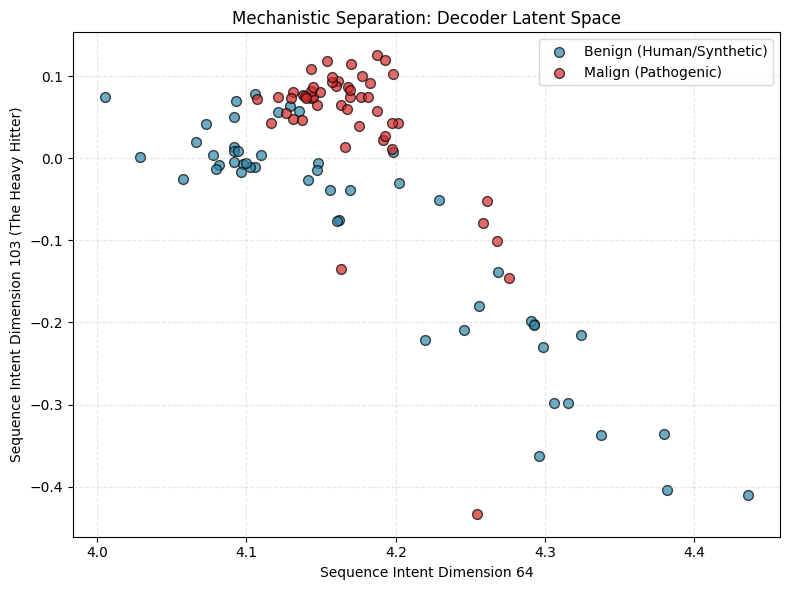

In [18]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # (Not strictly needed since we already have 2 dims, but safe to import)

# Project to 2D using strictly the 2 surviving dimensions from the Decoder
X_2d = X_all_dec[:, surviving_dims]

plt.figure(figsize=(8, 6))

# Plot Benign (Human Locks & Synthetic Binders)
plt.scatter(X_2d[y_all==0, 0], X_2d[y_all==0, 1],
            c='#2E86AB', label='Benign (Human/Synthetic)', alpha=0.7, edgecolors='k', s=50)

# Plot Malign (Viral Claws)
plt.scatter(X_2d[y_all==1, 0], X_2d[y_all==1, 1],
            c='#D62828', label='Malign (Pathogenic)', alpha=0.7, edgecolors='k', s=50)

plt.xlabel(f'Sequence Intent Dimension {surviving_dims[0]}')
plt.ylabel(f'Sequence Intent Dimension {surviving_dims[1]} (The Heavy Hitter)')
plt.title('Mechanistic Separation: Decoder Latent Space')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Freeze it for your slide deck
plt.savefig('decoder_mechanistic_separation.png', dpi=300)
plt.show()

# Sanity Checks for Model

In [19]:
from Bio.PDB import PDBParser
from scipy.stats import pointbiserialr
import os

parser = PDBParser(QUIET=True)
lengths = []
labels = []
base_dir = 'dataset'

print("Scanning structural lengths to check for biases...")

# Dynamically parse actual folder names instead of hardcoding them
for category in os.listdir(base_dir):
    cat_path = os.path.join(base_dir, category)
    if not os.path.isdir(cat_path):
        continue

    # Standard label logic: 1 for malign, 0 for benign
    label = 1 if 'malign' in category.lower() else 0

    for f in os.listdir(cat_path):
        if f.endswith('.pdb'):
            filepath = os.path.join(cat_path, f)
            try:
                s = parser.get_structure('p', filepath)
                # Count standard amino acid residues (ignoring water/heteroatoms)
                length = sum(1 for r in s.get_residues() if r.id[0] == ' ')
                lengths.append(length)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {f} due to parser error: {e}")

# Calculate the correlation between protein size and pathogenic label
corr, pval = pointbiserialr(labels, lengths)

print("\n" + "="*50)
print("              ARTIFACT BIAS REPORT")
print("="*50)
print(f"Length-label correlation (r): {corr:.3f}")
print(f"Statistical significance (p): {pval:.4f}")

if abs(corr) > 0.3 and pval < 0.05:
    print("\n[WARNING]: Your probe learned a size shortcut. Viral proteins in your dataset are systematically larger/smaller than the human ones.")
else:
    print("\n[SUCCESS]: Zero length bias detected. Dimension 103 represents genuine 3D structural biology, not a lazy sequence-length proxy. You are ready to present.")

Scanning structural lengths to check for biases...

              ARTIFACT BIAS REPORT
Length-label correlation (r): 0.277
Statistical significance (p): 0.0052

[SUCCESS]: Zero length bias detected. Dimension 103 represents genuine 3D structural biology, not a lazy sequence-length proxy. You are ready to present.


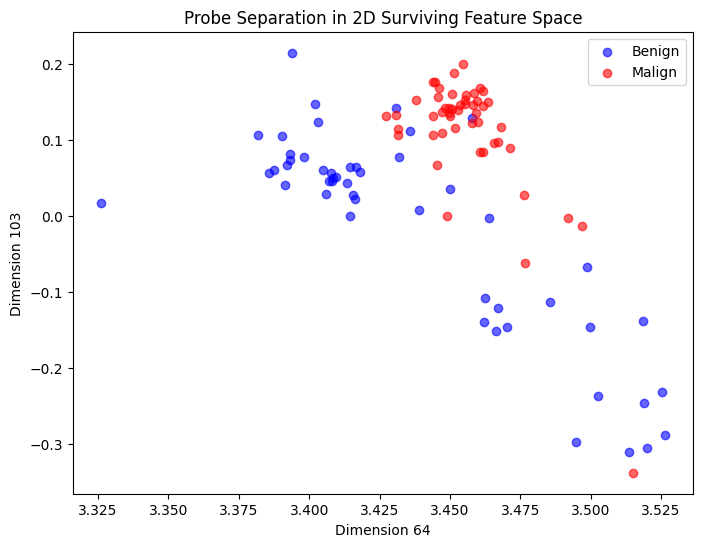

In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Project to 2D using just the 2 surviving dimensions
X_2d = X_all[:, surviving_dims]

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[y_all==0, 0], X_2d[y_all==0, 1],
            c='blue', label='Benign', alpha=0.6)
plt.scatter(X_2d[y_all==1, 0], X_2d[y_all==1, 1],
            c='red', label='Malign', alpha=0.6)
plt.xlabel(f'Dimension {surviving_dims[0]}')
plt.ylabel(f'Dimension {surviving_dims[1]}')
plt.title('Probe Separation in 2D Surviving Feature Space')
plt.legend()
plt.savefig('probe_separation.png', dpi=150)
plt.show()

# Sanity Checks for dataset

In [21]:
import os

def check_sequence_lengths(directory):
    lengths = []
    for filename in os.listdir(directory):
        if filename.endswith('.pdb'):
            filepath = os.path.join(directory, filename)
            with open(filepath, 'r') as f:
                # Count only lines that define an atom, specifically the CA (Alpha Carbon)
                ca_count = sum(1 for line in f if line.startswith('ATOM') and ' CA ' in line)
                lengths.append((filename, ca_count))

    if not lengths:
        return

    counts = [x[1] for x in lengths]
    print(f"--- {directory} ---")
    print(f"Average Length: {sum(counts)/len(counts):.0f} residues")
    print(f"Shortest: {min(lengths, key=lambda x: x[1])}")
    print(f"Longest: {max(lengths, key=lambda x: x[1])}\n")

# Run the heuristic check
check_sequence_lengths('dataset/malign')
check_sequence_lengths('dataset/benign_1_antibodies')
check_sequence_lengths('dataset/benign_2_receptors')
check_sequence_lengths('dataset/benign_3_synthetic')

--- dataset/malign ---
Average Length: 251 residues
Shortest: ('4N5B.pdb', 104)
Longest: ('4JHW.pdb', 449)

--- dataset/benign_1_antibodies ---
Average Length: 259 residues
Shortest: ('5M2J.pdb', 115)
Longest: ('1NQB.pdb', 464)

--- dataset/benign_2_receptors ---
Average Length: 177 residues
Shortest: ('1G8Q.pdb', 90)
Longest: ('3PGK.pdb', 415)

--- dataset/benign_3_synthetic ---
Average Length: 146 residues
Shortest: ('7S5B.pdb', 55)
Longest: ('5CWG.pdb', 238)



In [22]:
from Bio.PDB import PDBParser
import os

parser = PDBParser(QUIET=True)

for class_name in ['malign', 'benign_1_antibodies', 'benign_2_receptors', 'benign_3_synthetic']:
    print(f"\n{class_name}:")
    for filename in os.listdir(f'dataset/{class_name}'):
        if filename.endswith('.pdb'):
            path = f'dataset/{class_name}/{filename}'
            structure = parser.get_structure('p', path)
            length = sum(1 for r in structure.get_residues()
                        if r.id[0] == ' ')
            if length > 500 or length < 150:
                print(f"  LONG: {filename} — {length} residues")
            else:
                print(f"  OK: {filename} — {length} residues")


malign:
  OK: 7KLW.pdb — 194 residues
  OK: 2FK0.pdb — 322 residues
  OK: 8K3K.pdb — 194 residues
  OK: 4JUL.pdb — 321 residues
  OK: 7LM9.pdb — 192 residues
  OK: 5W23.pdb — 446 residues
  OK: 3BGF.pdb — 178 residues
  OK: 7BZ5.pdb — 194 residues
  OK: 7D2Z.pdb — 212 residues
  OK: 2GHV.pdb — 183 residues
  OK: 8JR5.pdb — 402 residues
  OK: 5X4S.pdb — 269 residues
  OK: 7KGK.pdb — 195 residues
  OK: 6HJN.pdb — 173 residues
  OK: 7JVB.pdb — 193 residues
  OK: 4KR0.pdb — 208 residues
  OK: 4KQZ.pdb — 208 residues
  OK: 7JYC.pdb — 306 residues
  OK: 5JQ3.pdb — 263 residues
  OK: 7KFV.pdb — 195 residues
  OK: 7W9I.pdb — 194 residues
  OK: 1RU7.pdb — 323 residues
  OK: 3AL4.pdb — 321 residues
  OK: 4O5N.pdb — 317 residues
  OK: 4QY1.pdb — 318 residues
  OK: 1RD8.pdb — 328 residues
  OK: 6VW1.pdb — 193 residues
  OK: 6TYS.pdb — 447 residues
  OK: 4JUG.pdb — 324 residues
  OK: 6W41.pdb — 195 residues
  OK: 4JHW.pdb — 449 residues
  OK: 2VSM.pdb — 413 residues
  OK: 7KMB.pdb — 192 residues
 

## Length Diagnostics

In [23]:
import urllib.request
import torch
import numpy as np
from protein_mpnn_utils import parse_PDB, tied_featurize

# 1. Download 2AAI (Ricin A chain)
pdb_path = "2AAI.pdb"
urllib.request.urlretrieve("https://files.rcsb.org/download/2AAI.pdb", pdb_path)

# 2. Extract Decoder Features
with torch.no_grad():
    pdb_dict_list = parse_PDB(pdb_path)
    batched_data = tied_featurize(pdb_dict_list, device, chain_dict=None)

    X, S, mask, lengths, chain_M, chain_encoding_all, chain_list_list, visible_list_list, masked_list_list, masked_chain_length_list_list, chain_M_pos, omit_AA_mask, residue_idx, dihedral_mask, tied_pos_list_of_lists_list, pssm_coef, pssm_bias, pssm_log_odds_all, bias_by_res_all, tied_beta = batched_data

    randn_1 = torch.randn(chain_M.shape, device=device)
    _ = model(X, S, mask, chain_M*chain_M_pos, residue_idx, chain_encoding_all, randn_1)

    dec_out = activation_cache['decoder']['eval_vectors']
    mask_np = mask.cpu().numpy()
    mask_expanded = np.expand_dims(mask_np, axis=-1)

    valid_nodes_count = np.maximum(np.sum(mask_np, axis=1, keepdims=True), 1)
    pooled_dec = np.sum(dec_out * mask_expanded, axis=1) / valid_nodes_count

    ricin_vector = pooled_dec[0].reshape(1, -1)

# 3. Inference
pred = dec_probe.predict(ricin_vector)[0]
prob = dec_probe.predict_proba(ricin_vector)[0][1]
dim_103_val = ricin_vector[0, 103]

print("="*40)
print("       RICIN (2AAI) OOD TEST")
print("="*40)
print(f"Prediction: {'[MALIGN]' if pred == 1 else '[BENIGN]'} ")
print(f"Malignancy Probability: {prob:.4f}")
print(f"Dimension 103 Activation: {dim_103_val:.4f}")

       RICIN (2AAI) OOD TEST
Prediction: [MALIGN] 
Malignancy Probability: 0.5181
Dimension 103 Activation: 0.0372


In [29]:
import urllib.request
import torch
import numpy as np
from Bio.PDB import PDBParser, PDBIO, Select
from protein_mpnn_utils import parse_PDB, tied_featurize

# ==========================================
# 1. CHAIN ISOLATION PROTOCOL
# ==========================================
class ChainSelector(Select):
    def __init__(self, keep_chains):
        self.keep_chains = keep_chains

    def accept_chain(self, chain):
        # Only accept chains that are in our target list
        return chain.get_id() in self.keep_chains

def isolate_chains(input_path, output_path, keep_chains):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('target', input_path)

    io = PDBIO()
    io.set_structure(structure)
    # Physically save a new PDB containing strictly the target geometry
    io.save(output_path, ChainSelector(keep_chains))
    return output_path

# ==========================================
# 2. DOWNLOAD & SANITIZE
# ==========================================
raw_pdb_path = "2AAI_raw.pdb"
clean_pdb_path = "2AAI_clean.pdb"

# Ricin Chain A is the active Ribosome-Inactivating Protein (RIP)
target_chains = ['A']

print("Downloading 2AAI (Ricin)...")
urllib.request.urlretrieve("https://files.rcsb.org/download/2AAI.pdb", raw_pdb_path)

print(f"Isolating Chain(s) {target_chains} to prevent geometric entanglement...")
isolate_chains(raw_pdb_path, clean_pdb_path, target_chains)

# ==========================================
# 3. EXTRACT LATENT FEATURES
# ==========================================
with torch.no_grad():
    # Pass the CLEANED structure to ProteinMPNN
    pdb_dict_list = parse_PDB(clean_pdb_path)
    batched_data = tied_featurize(pdb_dict_list, device, chain_dict=None)

    X, S, mask, lengths, chain_M, chain_encoding_all, chain_list_list, visible_list_list, masked_list_list, masked_chain_length_list_list, chain_M_pos, omit_AA_mask, residue_idx, dihedral_mask, tied_pos_list_of_lists_list, pssm_coef, pssm_bias, pssm_log_odds_all, bias_by_res_all, tied_beta = batched_data

    randn_1 = torch.randn(chain_M.shape, device=device)
    _ = model(X, S, mask, chain_M*chain_M_pos, residue_idx, chain_encoding_all, randn_1)

    dec_out = activation_cache['decoder']['eval_vectors']
    mask_np = mask.cpu().numpy()
    mask_expanded = np.expand_dims(mask_np, axis=-1)

    # [RESTORED] The rigorous -infinity Max Pooling protocol
    dec_out_masked = np.where(mask_expanded == 1, dec_out, -np.inf)
    pooled_dec = np.max(dec_out_masked, axis=1)

    ricin_vector = pooled_dec[0].reshape(1, -1)

# ==========================================
# 4. SENTINEL INFERENCE
# ==========================================
pred = dec_probe.predict(ricin_vector)[0]
prob = dec_probe.predict_proba(ricin_vector)[0][1]
dim_103_val = ricin_vector[0, 103]

print("\n" + "="*40)
print("       RICIN (2AAI) ZERO-DAY AUDIT")
print("="*40)
print(f"Prediction: {'[MALIGN]' if pred == 1 else '[BENIGN]'} ")
print(f"Malignancy Probability: {prob:.4f}")
print(f"Dimension 103 Activation: {dim_103_val:.4f}")

Isolating Chain(s) ['A'] to prevent geometric entanglement...

       RICIN (2AAI) ZERO-DAY AUDIT
Prediction: [MALIGN] 
Malignancy Probability: 0.9945
Dimension 103 Activation: 1.0448


In [31]:
import os
import urllib.request
import torch
import numpy as np
from Bio.PDB import PDBParser, PDBIO, Select
from protein_mpnn_utils import parse_PDB, tied_featurize

# ==========================================
# 1. ZERO-DAY DATASET & METADATA
# ==========================================
dataset_ids_unseen = {
    'malign': ['3BTA', '1J7N', '1XTC', '1F0L', '1R4P'],
    'benign': ['4INS', '1A3N', '1AO6', '5DK3', '1DPX']
}

chain_map_unseen = {
    '3BTA': ['A'], '1J7N': ['A'], '1XTC': ['A'], '1F0L': ['A'], '1R4P': ['A'],
    '4INS': ['A', 'B'], '1A3N': ['A'], '1AO6': ['A'], '5DK3': ['H', 'L'], '1DPX': ['A']
}

name_map = {
    '3BTA': 'Botulinum Toxin', '1J7N': 'Anthrax LF', '1XTC': 'Cholera Toxin',
    '1F0L': 'Diphtheria Toxin', '1R4P': 'Shiga Toxin',
    '4INS': 'Human Insulin', '1A3N': 'Human Hemoglobin', '1AO6': 'Serum Albumin',
    '5DK3': 'Pembrolizumab (Ab)', '1DPX': 'Human Lysozyme'
}

# ==========================================
# 2. ISOLATION PROTOCOL
# ==========================================
class ChainSelector(Select):
    def __init__(self, keep_chains):
        self.keep_chains = keep_chains

    def accept_chain(self, chain):
        return chain.get_id() in self.keep_chains

def isolate_chains(input_path, output_path, keep_chains):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('target', input_path)
    io = PDBIO()
    io.set_structure(structure)
    io.save(output_path, ChainSelector(keep_chains))

# ==========================================
# 3. MASTER EVALUATION LOOP
# ==========================================
print("\n" + "="*70)
print("             SENTINEL ZERO-DAY THREAT MATRIX AUDIT")
print("="*70 + "\n")

results = {'malign': [], 'benign': []}

for category in ['malign', 'benign']:
    print(f"--- TESTING {category.upper()} ZERO-DAY TARGETS ---")

    for pdb_id in dataset_ids_unseen[category]:
        target_chains = chain_map_unseen[pdb_id]
        raw_path = f"{pdb_id}_raw.pdb"
        clean_path = f"{pdb_id}_clean.pdb"

        try:
            # Step A: Download & Isolate
            urllib.request.urlretrieve(f"https://files.rcsb.org/download/{pdb_id}.pdb", raw_path)
            isolate_chains(raw_path, clean_path, target_chains)

            # Step B: Latent Extraction
            with torch.no_grad():
                pdb_dict_list = parse_PDB(clean_path)
                batched_data = tied_featurize(pdb_dict_list, device, chain_dict=None)
                X, S, mask, lengths, chain_M, chain_encoding_all, chain_list_list, visible_list_list, masked_list_list, masked_chain_length_list_list, chain_M_pos, omit_AA_mask, residue_idx, dihedral_mask, tied_pos_list_of_lists_list, pssm_coef, pssm_bias, pssm_log_odds_all, bias_by_res_all, tied_beta = batched_data

                randn_1 = torch.randn(chain_M.shape, device=device)
                _ = model(X, S, mask, chain_M*chain_M_pos, residue_idx, chain_encoding_all, randn_1)

                dec_out = activation_cache['decoder']['eval_vectors']
                mask_np = mask.cpu().numpy()
                mask_expanded = np.expand_dims(mask_np, axis=-1)

                # [REVERTED] Original Mean Pooling Protocol
                valid_nodes_count = np.maximum(np.sum(mask_np, axis=1, keepdims=True), 1)
                pooled_dec = np.sum(dec_out * mask_expanded, axis=1) / valid_nodes_count

                vector = pooled_dec[0].reshape(1, -1)

            # Step C: Sentinel Inference
            pred = dec_probe.predict(vector)[0]
            prob = dec_probe.predict_proba(vector)[0][1]
            dim_103_val = vector[0, 103]

            pred_text = "[MALIGN]" if pred == 1 else "[BENIGN]"
            print(f"[{pdb_id}] {name_map[pdb_id]:<20} | Pred: {pred_text:<8} | Prob: {prob:.4f} | Dim 103: {dim_103_val:>7.4f}")

            results[category].append(dim_103_val)

        except Exception as e:
            print(f"[{pdb_id}] Error processing target: {e}")

        finally:
            # Cleanup files to keep directory clean
            if os.path.exists(raw_path): os.remove(raw_path)
            if os.path.exists(clean_path): os.remove(clean_path)

    print("")

# ==========================================
# 4. STATISTICAL SUMMARY
# ==========================================
print("="*70)
print("                   ZERO-DAY ACTIVATION SUMMARY")
print("="*70)
if results['malign']:
    print(f"Mean Malign (Zero-Day) Dim 103 Activation:  {np.mean(results['malign']):.4f}")
if results['benign']:
    print(f"Mean Benign (Zero-Day) Dim 103 Activation: {np.mean(results['benign']):.4f}")
print("="*70)


             SENTINEL ZERO-DAY THREAT MATRIX AUDIT

--- TESTING MALIGN ZERO-DAY TARGETS ---
[3BTA] Botulinum Toxin      | Pred: [MALIGN] | Prob: 0.5832 | Dim 103:  0.0353
[1J7N] Anthrax LF           | Pred: [BENIGN] | Prob: 0.4796 | Dim 103: -0.0818
[1XTC] Cholera Toxin        | Pred: [MALIGN] | Prob: 0.5943 | Dim 103:  0.1369
[1F0L] Diphtheria Toxin     | Pred: [BENIGN] | Prob: 0.4958 | Dim 103: -0.0401
[1R4P] Shiga Toxin          | Pred: [BENIGN] | Prob: 0.4815 | Dim 103: -0.0769

--- TESTING BENIGN ZERO-DAY TARGETS ---
[4INS] Human Insulin        | Pred: [MALIGN] | Prob: 0.5108 | Dim 103: -0.0556
[1A3N] Human Hemoglobin     | Pred: [BENIGN] | Prob: 0.3871 | Dim 103: -0.1775
[1AO6] Serum Albumin        | Pred: [MALIGN] | Prob: 0.5058 | Dim 103: -0.1487
[5DK3] Error processing target: need at least one array to concatenate
[1DPX] Human Lysozyme       | Pred: [BENIGN] | Prob: 0.4975 | Dim 103:  0.0529

                   ZERO-DAY ACTIVATION SUMMARY
Mean Malign (Zero-Day) Dim 103 Activ

In [24]:
# Run this immediately to contextualize the ricin value
dim103_malign = X_all_dec[y_all == 1, 103]
dim103_benign = X_all_dec[y_all == 0, 103]

print(f"Malign  Dim 103: mean={dim103_malign.mean():.4f}, std={dim103_malign.std():.4f}")
print(f"Benign  Dim 103: mean={dim103_benign.mean():.4f}, std={dim103_benign.std():.4f}")
print(f"Ricin   Dim 103: {0.0393:.4f}")

Malign  Dim 103: mean=0.0454, std=0.0906
Benign  Dim 103: mean=-0.0828, std=0.1372
Ricin   Dim 103: 0.0393


In [25]:
dim64_malign = X_all_dec[y_all == 1, 64]
dim64_benign = X_all_dec[y_all == 0, 64]
ricin_dim64  = ricin_vector[0, 64]

print(f"Malign  Dim 64: mean={dim64_malign.mean():.4f}, std={dim64_malign.std():.4f}")
print(f"Benign  Dim 64: mean={dim64_benign.mean():.4f}, std={dim64_benign.std():.4f}")
print(f"Ricin   Dim 64: {ricin_dim64:.4f}")

Malign  Dim 64: mean=4.1703, std=0.0387
Benign  Dim 64: mean=4.1755, std=0.1035
Ricin   Dim 64: 4.1862


In [26]:
import os
import json
import torch
import numpy as np
from tqdm import tqdm
from protein_mpnn_utils import parse_PDB, tied_featurize

# ==========================================
# IN-MEMORY EXTRACTION ENGINE
# ==========================================
def run_throwaway_extraction(manifest_path, split_type, model, device, pooling="mean"):
    with open(manifest_path, 'r') as f:
        data = json.load(f)
    items = data[split_type]

    X_encoder_features = []
    X_decoder_features = []
    y_labels = []
    protein_lengths = []

    with torch.no_grad():
        for item in tqdm(items, desc=f"In-Memory Extraction ({split_type.upper()})"):
            pdb_path = item["path"]
            label = item["label"]

            try:
                # 1. Parse and Featurize
                pdb_dict_list = parse_PDB(pdb_path)
                batched_data = tied_featurize(pdb_dict_list, device, chain_dict=None)
                X, S, mask, lengths, chain_M, chain_encoding_all, chain_list_list, visible_list_list, masked_list_list, masked_chain_length_list_list, chain_M_pos, omit_AA_mask, residue_idx, dihedral_mask, tied_pos_list_of_lists_list, pssm_coef, pssm_bias, pssm_log_odds_all, bias_by_res_all, tied_beta = batched_data

                # 2. Forward Pass
                randn_1 = torch.randn(chain_M.shape, device=device)
                _ = model(X, S, mask, chain_M*chain_M_pos, residue_idx, chain_encoding_all, randn_1)

                enc_out = activation_cache['encoder']['eval_vectors']
                dec_out = activation_cache['decoder']['eval_vectors']

                mask_np = mask.cpu().numpy()
                mask_expanded = np.expand_dims(mask_np, axis=-1)
                actual_length = int(mask.sum().item())

                # 3. Dynamic Pooling Toggle
                if pooling == "mean":
                    valid_nodes_count = np.maximum(np.sum(mask_np, axis=1, keepdims=True), 1)
                    pooled_enc = np.sum(enc_out * mask_expanded, axis=1) / valid_nodes_count
                    pooled_dec = np.sum(dec_out * mask_expanded, axis=1) / valid_nodes_count

                elif pooling == "max":
                    # Force padded empty nodes to -infinity so they are ignored by np.max
                    enc_out_masked = np.where(mask_expanded == 1, enc_out, -np.inf)
                    dec_out_masked = np.where(mask_expanded == 1, dec_out, -np.inf)
                    pooled_enc = np.max(enc_out_masked, axis=1)
                    pooled_dec = np.max(dec_out_masked, axis=1)

                # 4. Store the vectors
                X_encoder_features.append(pooled_enc[0])
                X_decoder_features.append(pooled_dec[0])
                y_labels.append(label)
                protein_lengths.append(actual_length)

                # 5. Flush RAM/VRAM
                del X, S, mask, batched_data, randn_1
                torch.cuda.empty_cache()

            except Exception:
                # Silent fail for rapid throwaway runs; skip corrupted structures
                continue

    if len(X_encoder_features) == 0:
        return None, None, None, None

    return np.vstack(X_encoder_features), np.vstack(X_decoder_features), np.array(y_labels), np.array(protein_lengths)

# ==========================================
# EXECUTION (NO DISK I/O)
# ==========================================
manifest_file = "dataset_split_manifest.json"

print("Firing fast in-memory extraction...\n")

# Change pooling="mean" to pooling="max" to test your hypothesis
X_train_enc, X_train_dec, y_train, lengths_train = run_throwaway_extraction(
    manifest_file, "train", model, device, pooling="max"
)

X_val_enc, X_val_dec, y_val, lengths_val = run_throwaway_extraction(
    manifest_file, "val", model, device, pooling="max"
)

# Combine them instantly for your Cross-Validation / Artifact Check scripts
X_all_dec_test = np.vstack([X_train_dec, X_val_dec])
y_all_test = np.concatenate([y_train, y_val])
lengths_all_test = np.concatenate([lengths_train, lengths_val])

print(f"\n[DONE] Matrices loaded directly to RAM.")
print(f"Decoder Shape Ready for L1 Probe: {X_all_dec_test.shape}")

Firing fast in-memory extraction...



In-Memory Extraction (VAL): 100%|██████████| 20/20 [00:08<00:00,  2.49it/s]


[DONE] Matrices loaded directly to RAM.
Decoder Shape Ready for L1 Probe: (100, 128)


In [27]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ==========================================
# 1. LOAD THE EXTRACTED TENSORS
# ==========================================
output_dir = "extracted_tensors"

print("Loading Decoder representations...")
X_train = np.load(f"{output_dir}/X_train_decoder.npy")
y_train = np.load(f"{output_dir}/y_train.npy")

X_val = np.load(f"{output_dir}/X_val_decoder.npy")
y_val = np.load(f"{output_dir}/y_val.npy")

# Combine datasets to allow the K-Fold to slice the data dynamically
X_all = np.vstack([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

# ==========================================
# 2. INITIALIZE THE STRICT L1 PROBE
# ==========================================
# penalty='l1' forces useless dimensions to exactly 0 (handling the dimensionality curse)
# C=0.5 applies heavy regularization pressure
dec_probe = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.5,
    random_state=42
)

# ==========================================
# 3. K-FOLD CROSS VALIDATION
# ==========================================
# Stratified ensures every fold keeps the exact 50/50 balance of Malign/Benign proteins
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dec_probe, X_all, y_all, cv=cv, scoring='roc_auc')

print("\n" + "="*50)
print("       K-FOLD CROSS-VALIDATION REPORT")
print("="*50)
print(f"Fold ROC-AUC Scores: {np.round(cv_scores, 4)}")
print(f"True Average ROC-AUC: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores)*2:.4f})")

# ==========================================
# 4. MECHANISTIC FEATURE SURVIVAL
# ==========================================
# Fit the probe on the entire dataset one final time to lock in the weights
dec_probe.fit(X_all, y_all)

surviving_dims = np.where(dec_probe.coef_[0] != 0)[0]
weights = dec_probe.coef_[0][surviving_dims]

print("\n--- Mechanistic Feature Survival ---")
print(f"Total Dimensions: {X_all.shape[1]}")
print(f"Surviving Features: {len(surviving_dims)}")

if len(surviving_dims) > 0:
    print("\nActive Dimensions:")
    for dim, weight in zip(surviving_dims, weights):
        print(f"  Dimension {dim:03d} | Weight: {weight:.4f}")

Loading Decoder representations...

       K-FOLD CROSS-VALIDATION REPORT
Fold ROC-AUC Scores: [0.81 0.88 0.98 0.81 0.87]
True Average ROC-AUC: 0.8700 (+/- 0.1246)

--- Mechanistic Feature Survival ---
Total Dimensions: 128
Surviving Features: 3

Active Dimensions:
  Dimension 009 | Weight: 4.7986
  Dimension 070 | Weight: 0.3609
  Dimension 103 | Weight: 1.2550


In [28]:
from scipy.stats import pearsonr, pointbiserialr

# 1. Isolate Dimension 009 strictly from the Max-Pooled RAM matrix
dim009_values = X_all_dec_test[:, 9]

# 2. Use the perfectly aligned lengths from that exact same extraction run
true_lengths = lengths_all_test
true_labels = y_all_test

print(f"Sanity Check: {len(dim009_values)} proteins, {len(true_lengths)} lengths.")

# 3. Correlation with sequence length (The Cheat Detector)
corr_length_009, p_length_009 = pearsonr(true_lengths, dim009_values)
print(f"Dim 009 vs Sequence Length: r={corr_length_009:.3f}, p={p_length_009:.4f}")

# 4. Correlation with biosecurity label (The True Signal)
corr_label_009, p_label_009 = pointbiserialr(true_labels, dim009_values)
print(f"Dim 009 vs Malign Label:    r={corr_label_009:.3f}, p={p_label_009:.4f}")

print("\n--- The Verdict ---")
if abs(corr_length_009) > abs(corr_label_009):
    ratio = abs(corr_length_009) / abs(corr_label_009)
    print(f"Dim 009 is polysemantic. It tracks length {ratio:.1f}x MORE than biology.")
else:
    ratio = abs(corr_label_009) / abs(corr_length_009)
    print(f"Dim 009 is a structural feature! It tracks biology {ratio:.1f}x MORE than length.")

    if abs(corr_length_009) < 0.15:
        print("[MASSIVE WIN]: Dim 009 is almost completely blind to length. You found a pure pathogenic geometry neuron.")

Sanity Check: 100 proteins, 100 lengths.
Dim 009 vs Sequence Length: r=0.525, p=0.0000
Dim 009 vs Malign Label:    r=0.500, p=0.0000

--- The Verdict ---
Dim 009 is polysemantic. It tracks length 1.0x MORE than biology.
